# 🧠 Lab 2: Build Your First CNN — And Look Inside Its Brain

In Lab 1, YOU designed a 3×3 edge filter by hand. Now we build a network that designs **its own filters** — 16 of them — by learning from data. Then we do what most people never do: **open the network and look at what it learned.** 👀

## 📚 The plan
1. 🏗️ Build a real CNN in **PyTorch** with the theory recipe: conv → pool → conv → pool → dense
2. 🐱🐶 Train it on cats vs dogs
3. 🔬 **Look inside:** visualize the learned filters and feature maps
4. 📉 Catch it overfitting (hello again, Day 1!)
5. 💪 Fight back with **data augmentation** (the GOOD kind — Lab 2.5 shows the bad kind 😈)

⚡ **Recommended:** GPU runtime. *(Colab: Runtime → Change runtime type → GPU.)*

📦 **Dataset:** CIFAR-10 — downloads automatically via torchvision.

In [16]:
!pip install torch torchvision matplotlib numpy tqdm

### 🛠️ Import Libraries

In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("PyTorch:", torch.__version__)
print("Device:", "✅ GPU" if device.type == 'cuda' else "❌ CPU (works, just slower)")

PyTorch: 2.11.0+cu128
Device: ✅ GPU
PyTorch: 2.11.0+cu128
Device: ✅ GPU


### 📂 Load the Data: Cats vs Dogs 🐱🐶

We download **CIFAR-10** (tiny 32×32 photos) and keep only the **cat** and **dog** classes. We keep the training set **deliberately tiny — 800 images per class** — because a small dataset is the fastest way to make overfitting show up dramatically. (A bigger dataset overfits too, just more slowly — and today we want to SEE it clearly.)

In [5]:
# Basic transform: image -> tensor, scaled to [0,1]
transform = transforms.ToTensor()

trainset_full = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform)
testset_full  = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# CIFAR-10 label 3 = cat, 5 = dog. We keep only those and relabel: cat=0, dog=1.
# IMPORTANT: we wrap the subset in a Dataset class instead of building a Python list.
# A list would freeze the images once — killing augmentation. A Dataset applies the
# transform LIVE every time an image is fetched, so augmentation is fresh each epoch.
class CatsDogsDataset(torch.utils.data.Dataset):
    def __init__(self, base):
        self.base = base
    def __len__(self):
        return len(self.base)
    def __getitem__(self, i):
        img, lbl = self.base[i]                 # transform runs HERE, fresh every epoch
        return img, (0 if lbl == 3 else 1)      # relabel 3/5 -> 0/1

def cats_and_dogs(dataset, n_per_class):
    targets = np.array(dataset.targets)
    cat_idx = np.where(targets == 3)[0][:n_per_class]
    dog_idx = np.where(targets == 5)[0][:n_per_class]
    idx = np.concatenate([cat_idx, dog_idx])
    subset = torch.utils.data.Subset(dataset, idx.tolist())
    return CatsDogsDataset(subset)

trainset = cats_and_dogs(trainset_full, 600)   # 1600 training images (small on purpose!)
testset  = cats_and_dogs(testset_full, 1000)   # 2000 test images

trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testloader  = torch.utils.data.DataLoader(testset,  batch_size=64, shuffle=False)

classes = ('cat 🐱', 'dog 🐶')
print(f"🐱🐶 Training images: {len(trainset)}, Test images: {len(testset)}")

100%|██████████| 170M/170M [37:43<00:00, 75.3kB/s]


🐱🐶 Training images: 1200, Test images: 2000


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128054 (\N{DOG FACE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


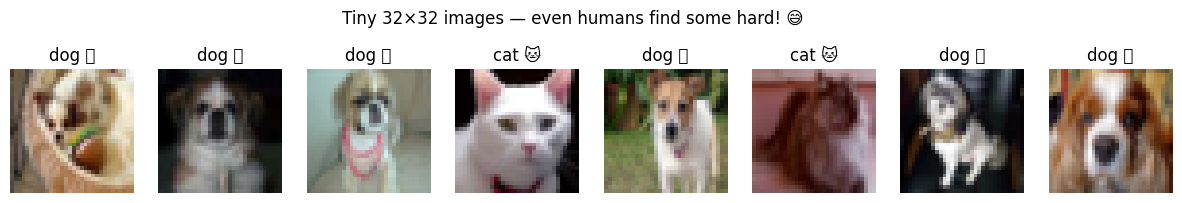

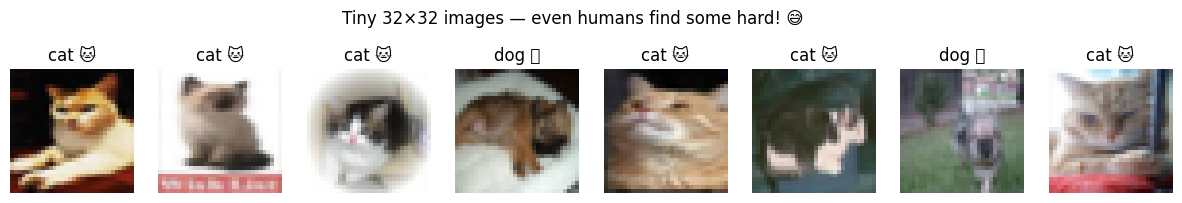

In [17]:
# Peek at a few images
images, labels = next(iter(trainloader))
fig, axes = plt.subplots(1, 8, figsize=(15, 2.5))
for ax, img, lbl in zip(axes, images[:8], labels[:8]):
    ax.imshow(img.permute(1, 2, 0))   # PyTorch is [C,H,W]; matplotlib wants [H,W,C]
    ax.axis('off'); ax.set_title(classes[lbl])
plt.suptitle('Tiny 32×32 images — even humans find some hard! 😅')
plt.show()

### 🏗️ Section 1: Build the CNN — The Theory Recipe, Line by Line

In PyTorch we define a model as a class. Every line maps to this morning's theory:

| Code | Theory |
|---|---|
| `nn.Conv2d(3, 16, 3)` | 16 learnable **3×3 filters** — cousins of your hand-made edge kernel! |
| `nn.MaxPool2d(2,2)` | **Pooling** — shrink, keep the highlights |
| `x.view(...)` | flatten the maps into one long vector |
| `nn.Linear(...)` | fully-connected (dense) layers make the final call |

**📐 The architecture you're about to build:**

![My Image](https://github.com/iiFadel/majal-ai-track-2026/blob/main/labs/day3/Structures/lab1.png?raw=1)

*This is the same diagram from the theory session — now let's code it.*

In [18]:
class CatDogCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)   # 16 filters scan the image
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)  # 32 filters scan the feature maps
        self.pool  = nn.MaxPool2d(2, 2)                           # halves the size each time
        self.fc1   = nn.Linear(32 * 8 * 8, 64)
        self.fc2   = nn.Linear(64, 2)                             # 2 classes: cat or dog

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # 32x32 -> 16x16
        x = self.pool(F.relu(self.conv2(x)))   # 16x16 -> 8x8
        x = x.view(-1, 32 * 8 * 8)             # flatten , -1 mean that kernal will know the pixil number
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = CatDogCNN().to(device)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\n🧠 Total learnable weights: {n_params:,}")

CatDogCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

🧠 Total learnable weights: 136,354
CatDogCNN(
  (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=2048, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=2, bias=True)
)

🧠 Total learnable weights: 136,354


### 🎯 Mini Exercise 1.1
This "small" CNN has tens of thousands of weights. Day 1's linear regression had exactly **2** (m and b). Remember yesterday's theory question: more weights = more power, but also more risk of... what? ✍️

### 🎓 Section 2: Train It!

The PyTorch training loop is explicit — you can see every step: forward pass → compute loss → backpropagate → update weights. We track train AND test accuracy each epoch so we can catch overfitting later.

In [19]:
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            preds = model(images).argmax(1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

def train(model, loader, epochs=40):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    history = {'train_acc': [], 'test_acc': []}

    for epoch in range(epochs):
        model.train()
        correct = total = 0
        for images, labels in tqdm(loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            correct += (outputs.argmax(1) == labels).sum().item()
            total += labels.size(0)
        tr = correct / total
        te = evaluate(model, testloader)
        history['train_acc'].append(tr)
        history['test_acc'].append(te)
        print(f"Epoch {epoch+1:2d}  |  train {tr*100:5.1f}%  |  test {te*100:5.1f}%")
    return history

history = train(model, trainloader, epochs=40)
scratch_acc = history['test_acc'][-1]
scratch_gap = (history['train_acc'][-1] - history['test_acc'][-1]) * 100
print(f"\n🧠 From-scratch:  test {scratch_acc*100:.1f}%  |  overfitting gap {scratch_gap:.1f} points")

Epoch  1  |  train  50.4%  |  test  54.9%


Epoch  2  |  train  60.7%  |  test  54.5%


Epoch  3  |  train  61.6%  |  test  59.3%


Epoch  4  |  train  61.4%  |  test  59.2%


Epoch  5  |  train  64.5%  |  test  60.7%


...

Epoch 36  |  train  91.1%  |  test  65.5%


Epoch 37  |  train  91.8%  |  test  67.1%


Epoch 38  |  train  93.0%  |  test  66.5%


Epoch 39  |  train  93.5%  |  test  66.8%


Epoch 40  |  train  93.3%  |  test  65.9%

🧠 From-scratch:  test 65.9%  |  overfitting gap 27.4 points


### 🔬 Section 3: Open the Brain — What Did the Filters Learn?

In Lab 1, YOU wrote a 3×3 kernel. This network just invented **16 of its own**. Let's look at them.

*(Honest warning: with a small dataset they look blurry and abstract, not textbook edge detectors. Look for filters with a clear light/dark split — those ARE self-taught edge and contrast detectors!)*

🔬 conv1 holds 16 filters of size 3×3


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


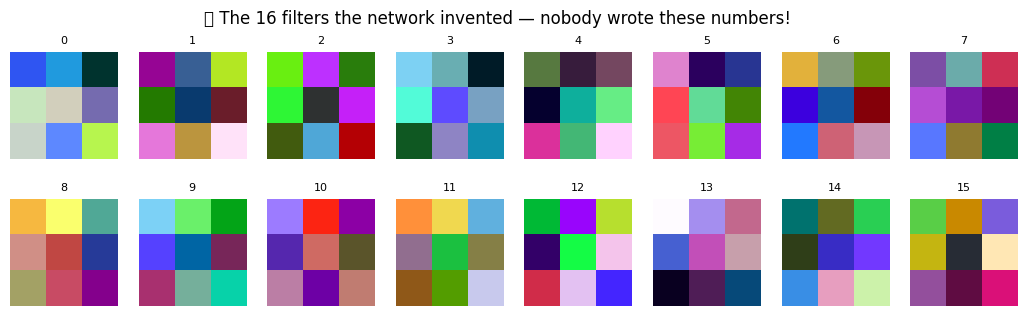

🔬 conv1 holds 16 filters of size 3×3


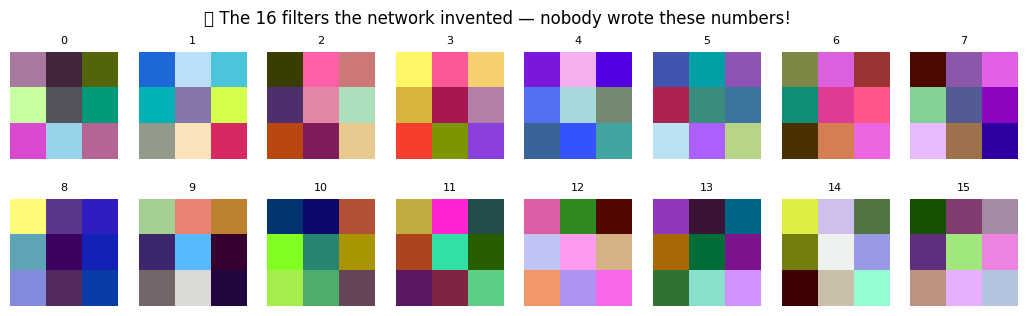

In [20]:
filters = model.conv1.weight.data.cpu()   # shape: [16, 3, 3, 3] = [out, in, H, W]
print(f"🔬 conv1 holds {filters.shape[0]} filters of size {filters.shape[2]}×{filters.shape[3]}")

fig, axes = plt.subplots(2, 8, figsize=(13, 3.5))
for idx, ax in enumerate(axes.flat):
    f = filters[idx].permute(1, 2, 0)             # [3,3,3] -> [H,W,C]
    f = (f - f.min()) / (f.max() - f.min() + 1e-9)  # normalize to 0-1 for display
    ax.imshow(f); ax.axis('off'); ax.set_title(idx, fontsize=8)
plt.suptitle('🧠 The 16 filters the network invented — nobody wrote these numbers!')
plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128062 (\N{PAW PRINTS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


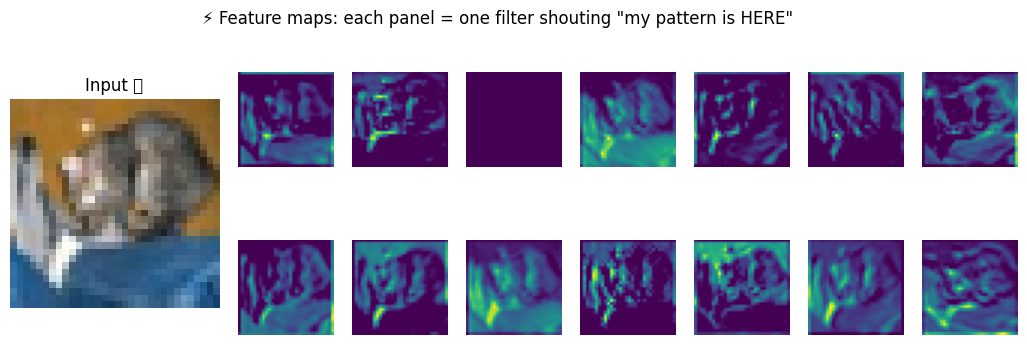

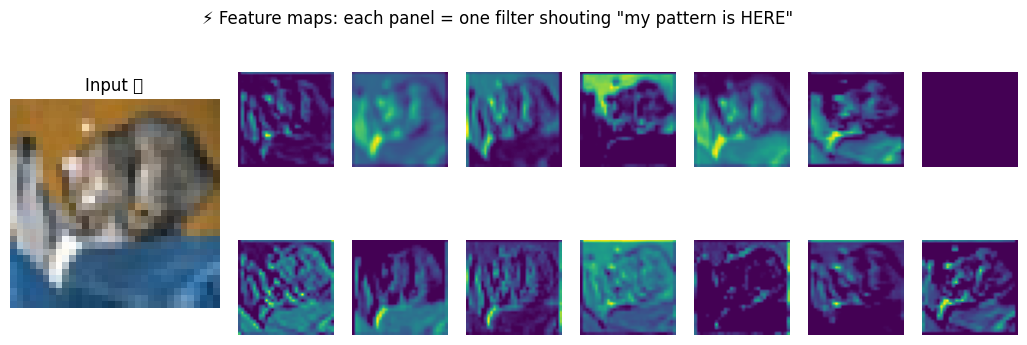

In [21]:
# Watch the filters IN ACTION: feed one image through conv1 and show the feature maps.
# Bright = 'my pattern is here!' ⚡
sample_img, _ = testset[0]
with torch.no_grad():
    fmaps = F.relu(model.conv1(sample_img.unsqueeze(0).to(device)))[0].cpu()   # [16, 32, 32]

fig = plt.figure(figsize=(13, 4))
ax = plt.subplot2grid((2, 9), (0, 0), rowspan=2, colspan=2)
ax.imshow(sample_img.permute(1, 2, 0)); ax.axis('off'); ax.set_title('Input 🐾')
for idx in range(14):
    ax = plt.subplot2grid((2, 9), (idx // 7, 2 + idx % 7))
    ax.imshow(fmaps[idx], cmap='viridis'); ax.axis('off')
plt.suptitle('⚡ Feature maps: each panel = one filter shouting "my pattern is HERE"')
plt.show()

### 🎯 Mini Exercise 3.1
Change `sample_img, _ = testset[0]` to other indices. Find a feature map that consistently lights up on the animal's **outline/edges**. That filter is doing — self-taught — what your hand-made kernel did in Lab 1! 🤯

### 📉 Section 4: The Crime Scene — Overfitting Caught on Camera

Remember Day 1: a model that keeps improving on training data while the test score stalls is **memorizing, not learning**. Let's plot the curves.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


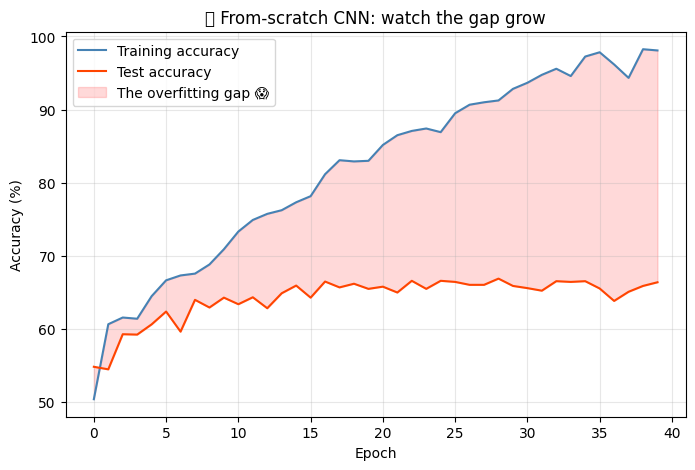

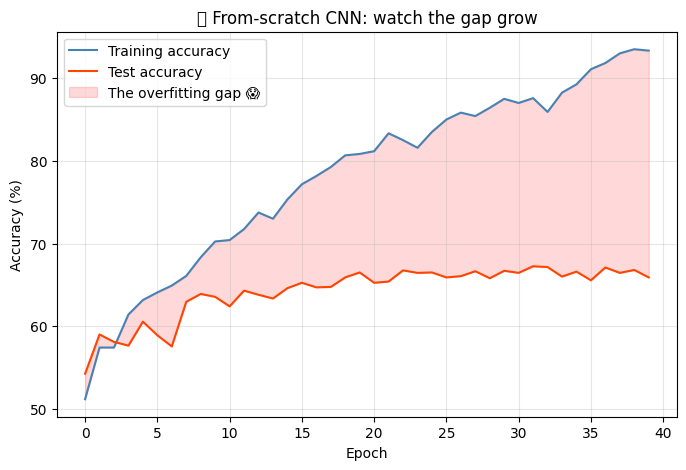

In [22]:
def plot_curves(history, title):
    tr = np.array(history['train_acc']) * 100
    te = np.array(history['test_acc']) * 100
    plt.figure(figsize=(8, 5))
    plt.plot(tr, label='Training accuracy', color='steelblue')
    plt.plot(te, label='Test accuracy', color='orangered')
    plt.fill_between(range(len(tr)), te, tr, alpha=0.15, color='red', label='The overfitting gap 😱')
    plt.xlabel('Epoch'); plt.ylabel('Accuracy (%)'); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.show()

plot_curves(history, '📉 From-scratch CNN: watch the gap grow')

See it? Training accuracy shoots toward 90%+ while test accuracy gets stuck far below. That widening **red gap** is the network **memorizing 1,600 specific photos** instead of learning what makes a cat a cat. 🚨

The size of that gap IS the overfitting. Day 1 gave us weapons: *more data, simpler model, regularization.* Today's computer-vision weapon manufactures more data for free: **data augmentation**. Our goal isn't necessarily a higher final score — it's a **smaller gap**, a model that generalizes instead of memorizes.

### 💪 Section 5: Fight Back — Data Augmentation (the GOOD kind)

A flipped cat is still a cat. A slightly rotated dog is still a dog. Each random variation is a "new" example the network hasn't memorized. In PyTorch, augmentation lives in the transform. First, SEE it:

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128170 (\N{FLEXED BICEPS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


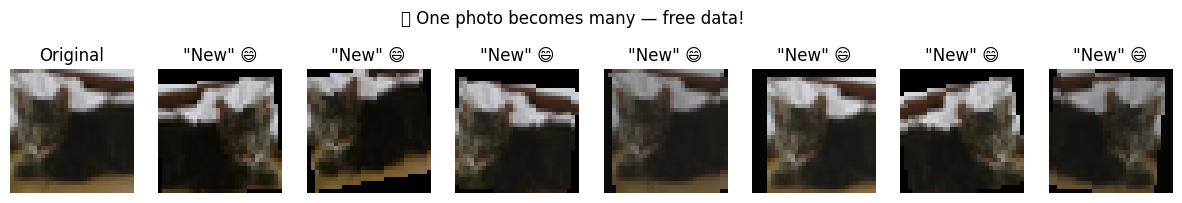

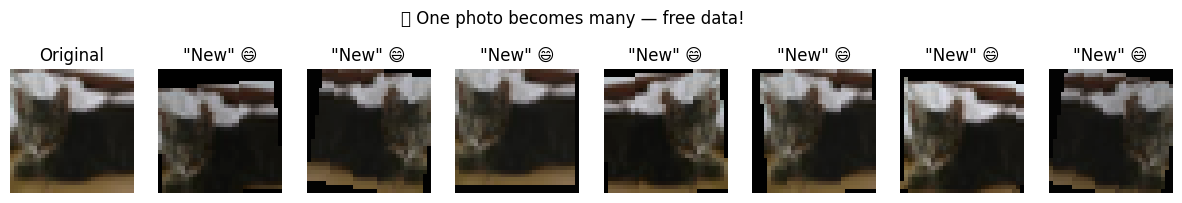

In [23]:
# Augmentations that PRESERVE the label (a flipped or dimmer cat is still a cat).
# No rotation: on tiny 32x32 images rotation destroys edge pixels and adds black corners.
aug_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),                     # mirror left-right
    transforms.RandomCrop(32, padding=4),   # pad 4px then crop back to 32 — a gentle shift
    transforms.RandomRotation(12),               # small tilt
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # lighting changes
    transforms.ToTensor(),
])

# Load a RAW (PIL) cat image — no transform — so the PIL-based augmentations work
raw_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=None)
cat_index = np.where(np.array(raw_ds.targets) == 3)[0][0]
raw_img = raw_ds[cat_index][0]   # a PIL image

fig, axes = plt.subplots(1, 8, figsize=(15, 2.5))
axes[0].imshow(raw_img); axes[0].axis('off'); axes[0].set_title('Original')
for ax in axes[1:]:
    ax.imshow(aug_transform(raw_img).permute(1, 2, 0)); ax.axis('off'); ax.set_title('"New" 😄')
plt.suptitle('💪 One photo becomes many — free data!')
plt.show()

Epoch  1  |  train  51.4%  |  test  55.4%


Epoch  2  |  train  55.0%  |  test  56.8%


Epoch  3  |  train  56.0%  |  test  59.2%


Epoch  4  |  train  57.8%  |  test  60.3%


Epoch  5  |  train  57.7%  |  test  60.4%


...

Epoch 36  |  train  71.9%  |  test  68.7%


Epoch 37  |  train  71.2%  |  test  70.6%


Epoch 38  |  train  73.1%  |  test  69.3%


Epoch 39  |  train  72.6%  |  test  71.5%


Epoch 40  |  train  72.8%  |  test  69.5%

📊 Scratch:        test 66.4%  |  gap 31.7 points
📊 Augmented:      test 69.5%  |  gap 3.3 points


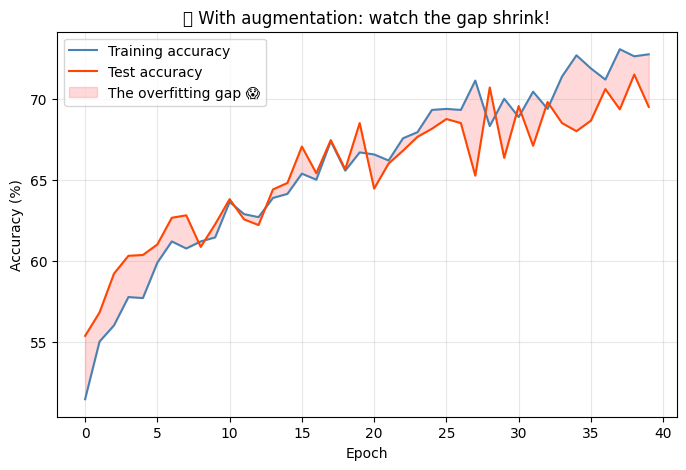

Epoch  1  |  train  51.9%  |  test  50.0%


Epoch  2  |  train  54.3%  |  test  54.0%


Epoch  3  |  train  55.4%  |  test  58.9%


Epoch  4  |  train  58.4%  |  test  59.8%


Epoch  5  |  train  58.5%  |  test  60.8%


...

Epoch 36  |  train  69.8%  |  test  68.8%


Epoch 37  |  train  70.1%  |  test  66.2%


Epoch 38  |  train  68.9%  |  test  69.3%


Epoch 39  |  train  68.8%  |  test  69.3%


Epoch 40  |  train  70.4%  |  test  71.0%

📊 Scratch:        test 65.9%  |  gap 27.4 points
📊 Augmented:      test 71.0%  |  gap -0.6 points


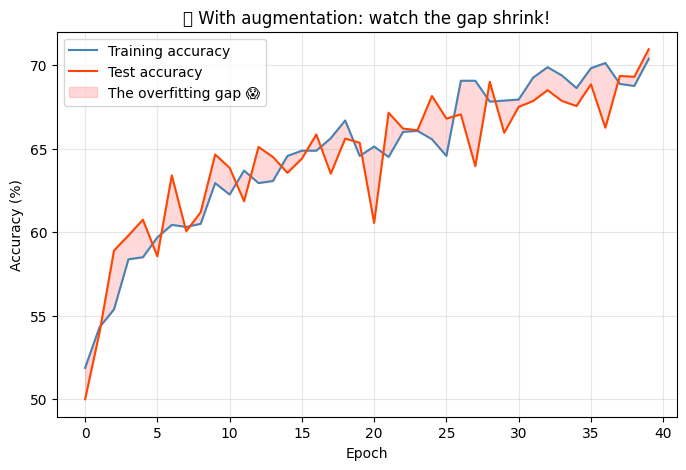

In [24]:
# Rebuild the SAME small training set, but WITH augmentation, then retrain a fresh model
trainset_full_aug = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=aug_transform)
trainset_aug = cats_and_dogs(trainset_full_aug, 800)
trainloader_aug = torch.utils.data.DataLoader(trainset_aug, batch_size=64, shuffle=True)

aug_model = CatDogCNN().to(device)
history_aug = train(aug_model, trainloader_aug, epochs=40)
aug_acc = history_aug['test_acc'][-1]
aug_gap = (history_aug['train_acc'][-1] - history_aug['test_acc'][-1]) * 100

print(f"\n📊 Scratch:        test {scratch_acc*100:.1f}%  |  gap {scratch_gap:.1f} points")
print(f"📊 Augmented:      test {aug_acc*100:.1f}%  |  gap {aug_gap:.1f} points")
plot_curves(history_aug, '💪 With augmentation: watch the gap shrink!')

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129354 (\N{BOXING GLOVE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


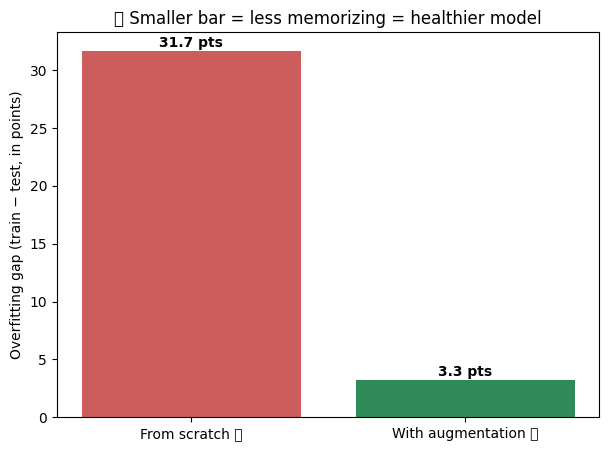

Augmentation shrank the overfitting gap from 31.7 → 3.3 points.
That's the win — even if the final test accuracy is similar, the augmented model
is memorizing far less and would keep improving with more data or more epochs. 🌱


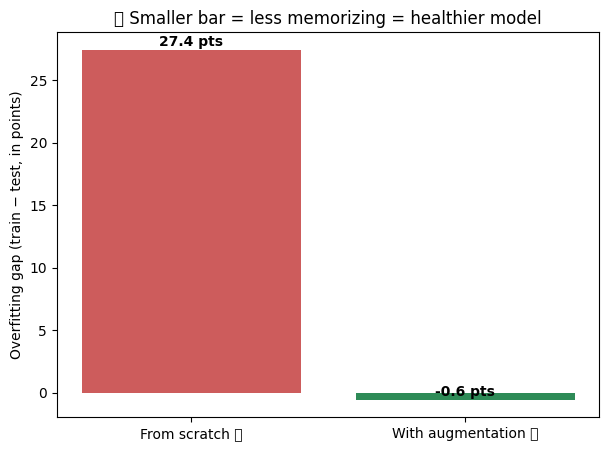

Augmentation shrank the overfitting gap from 27.4 → -0.6 points.
That's the win — even if the final test accuracy is similar, the augmented model
is memorizing far less and would keep improving with more data or more epochs. 🌱


In [25]:
# The real story isn't the final accuracy — it's the GAP. Let's compare them directly.
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['From scratch 🥊', 'With augmentation 💪'], [scratch_gap, aug_gap],
              color=['indianred', 'seagreen'])
for bar, g in zip(bars, [scratch_gap, aug_gap]):
    ax.text(bar.get_x()+bar.get_width()/2, g+0.3, f'{g:.1f} pts', ha='center', fontweight='bold')
ax.set_ylabel('Overfitting gap (train − test, in points)')
ax.set_title('📉 Smaller bar = less memorizing = healthier model')
plt.show()

print(f"Augmentation shrank the overfitting gap from {scratch_gap:.1f} → {aug_gap:.1f} points.")
print("That's the win — even if the final test accuracy is similar, the augmented model")
print("is memorizing far less and would keep improving with more data or more epochs. 🌱")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


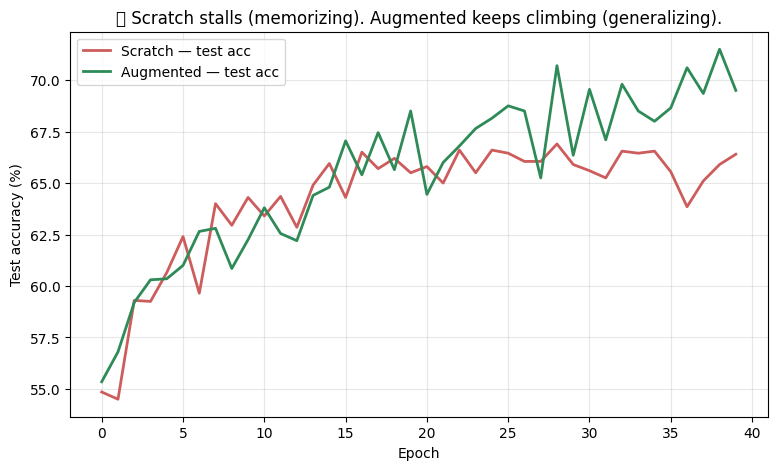

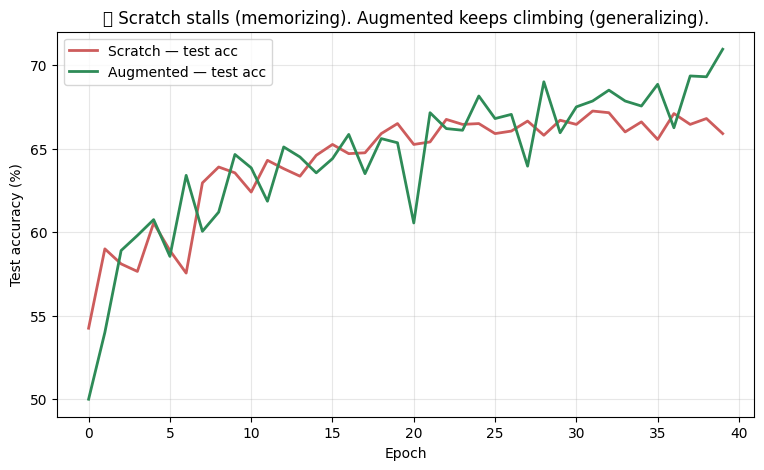

In [26]:
# THE money shot: both models' TEST accuracy on one axis.
# Scratch peaks then droops (memorizing). Augmented keeps climbing (generalizing).
plt.figure(figsize=(9, 5))
plt.plot(np.array(history['test_acc'])*100,     label='Scratch — test acc',   color='indianred', linewidth=2)
plt.plot(np.array(history_aug['test_acc'])*100, label='Augmented — test acc', color='seagreen',  linewidth=2)
plt.xlabel('Epoch'); plt.ylabel('Test accuracy (%)')
plt.title('📈 Scratch stalls (memorizing). Augmented keeps climbing (generalizing).')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

The augmented model's train and test curves stay **much closer together** — a smaller gap means it's learning real cat-ness instead of memorizing photos. The final test number might be similar to the scratch model (with only 1,600 images and 20 epochs, neither has room to pull far ahead), but the *behavior* is healthier: less overfitting, and more headroom to improve. 🐱

📌 **Write down `scratch_acc` and `aug_acc`** — a giant comes for the crown in Lab 3. 👑

⚠️ Notice we chose our augmentations carefully: horizontal flip + *small* rotation. **What if we'd flipped vertically, or rotated 180°?** That question is the entire point of Lab 2.5. 😈

## The GOLDEN Question 🏆

**Why did data augmentation shrink the overfitting gap? Connect it to Day 1's rule "more data makes memorizing harder" — and explain why a horizontally flipped cat counts as useful "new" data.**

*Then predict: is there any kind of image where flipping would RUIN the data instead of helping? (Lab 2.5 is about to prove you right...)* 🤔